# 01 Data quality and KPI overview

First pass over the analytics layer. The point of this notebook is to check that the models are trustworthy before anyone reads a conversion number off them, and then to set the baseline KPIs the rest of the analysis argues about.

Tables come from `sql/duckdb/`, which is a port of the BigQuery models in `sql/bigquery/`.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import pandas as pd

from ga4_growth import metrics, viz
from ga4_growth.warehouse import query

viz.setup()
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 60)

## What is in the warehouse

In [2]:
tables = ["stg_events", "fct_sessions", "fct_funnel", "fct_orders",
          "fct_product_performance", "dim_users", "fct_daily_kpis", "fct_cohort_retention"]

pd.DataFrame(
    [(t, query(f"SELECT count(*) AS n FROM {t}")["n"][0]) for t in tables],
    columns=["table", "rows"],
)

,table,rows
0,stg_events,2224827
1,fct_sessions,228210
2,fct_funnel,228210
3,fct_orders,4492
4,fct_product_performance,220
5,dim_users,150000
6,fct_daily_kpis,91
7,fct_cohort_retention,582


In [3]:
query("""
SELECT
  min(event_date)              AS first_day,
  max(event_date)              AS last_day,
  count(DISTINCT event_date)   AS days,
  count(DISTINCT event_id)     AS events,
  count(DISTINCT user_id)      AS users,
  count(DISTINCT session_id)   AS sessions
FROM stg_events
""")

,first_day,last_day,days,events,users,sessions
0,2024-09-01,2024-12-01,92,2198509,150000,228210


In [4]:
# Event mix. A funnel is only readable if the events behind it show up in
# sensible proportions.
query("""
SELECT event_name,
       count(DISTINCT event_id)   AS events,
       count(DISTINCT session_id) AS sessions,
       round(count(DISTINCT session_id) / (SELECT count(*) FROM fct_sessions), 4) AS session_coverage
FROM stg_events
GROUP BY 1
ORDER BY events DESC
""")

,event_name,events,sessions,session_coverage
0,page_view,877431,228210,1.0000
1,select_item,360547,144280,0.6322
2,view_item,360547,144280,0.6322
3,session_start,228210,228210,1.0000
4,first_visit,150000,150000,0.6573
5,view_item_list,144280,144280,0.6322
6,add_to_cart,34759,20991,0.0920
7,view_cart,16623,16623,0.0728
8,begin_checkout,7685,7685,0.0337
9,add_shipping_info,6243,6243,0.0274


## Data quality checks

Six checks, each written so that 0 means the model is clean. Anything that fails goes into `docs/limitations.md` instead of being quietly patched.

In [5]:
query("""
SELECT 'events without a session id' AS check_name,
       count(*) AS failing_rows
FROM stg_events WHERE ga_session_id IS NULL
UNION ALL
SELECT 'duplicate transaction ids',
       count(*) FROM (SELECT transaction_id FROM fct_orders GROUP BY 1 HAVING count(*) > 1)
UNION ALL
SELECT 'orders with zero or null value',
       count(*) FROM fct_orders WHERE coalesce(order_value, 0) <= 0
UNION ALL
SELECT 'purchases without an add_to_cart in the same session',
       count(*) FROM fct_funnel WHERE purchased AND NOT added_to_cart
UNION ALL
SELECT 'checkouts without an add_to_cart in the same session',
       count(*) FROM fct_funnel WHERE began_checkout AND NOT added_to_cart
UNION ALL
SELECT 'items missing a category',
       count(*) FROM stg_events WHERE product_id IS NOT NULL AND product_category IS NULL
""")

,check_name,failing_rows
0,events without a session id,0
1,duplicate transaction ids,0
2,orders with zero or null value,0
3,purchases without an add_to_cart in the same s...,0
4,checkouts without an add_to_cart in the same s...,0
5,items missing a category,0


In [6]:
# Reported revenue against the sum of the item rows on the same order. GA4
# exports these separately and they do not always agree, so the gap is worth
# measuring before revenue is reported to anyone.
query("""
SELECT
  count(*)                                                           AS orders,
  count(*) FILTER (WHERE abs(order_value - item_revenue_sum) > 0.01) AS orders_with_gap,
  round(sum(order_value), 2)                                         AS reported_revenue,
  round(sum(item_revenue_sum), 2)                                    AS item_level_revenue,
  round(sum(order_value) - sum(item_revenue_sum), 2)                 AS gap
FROM fct_orders
""")

,orders,orders_with_gap,reported_revenue,item_level_revenue,gap
0,4492,0,312481.13,312481.13,0.0


## Headline KPIs

One definition per metric, all of them coming from `ga4_growth.metrics`, so the notebooks, the Streamlit app and the Power BI extract cannot disagree.

In [7]:
metrics.headline_kpis().to_frame("value")

,value
users,150000.0000
sessions,228210.0000
returning_users,48983.0000
transactions,4492.0000
revenue,312481.1300
sessions_per_user,1.5210
product_view_rate,0.6322
view_to_cart_rate,0.1455
cart_to_checkout_rate,0.3661
checkout_to_purchase_rate,0.5845


'reports\\figures\\01_traffic_and_revenue.png'

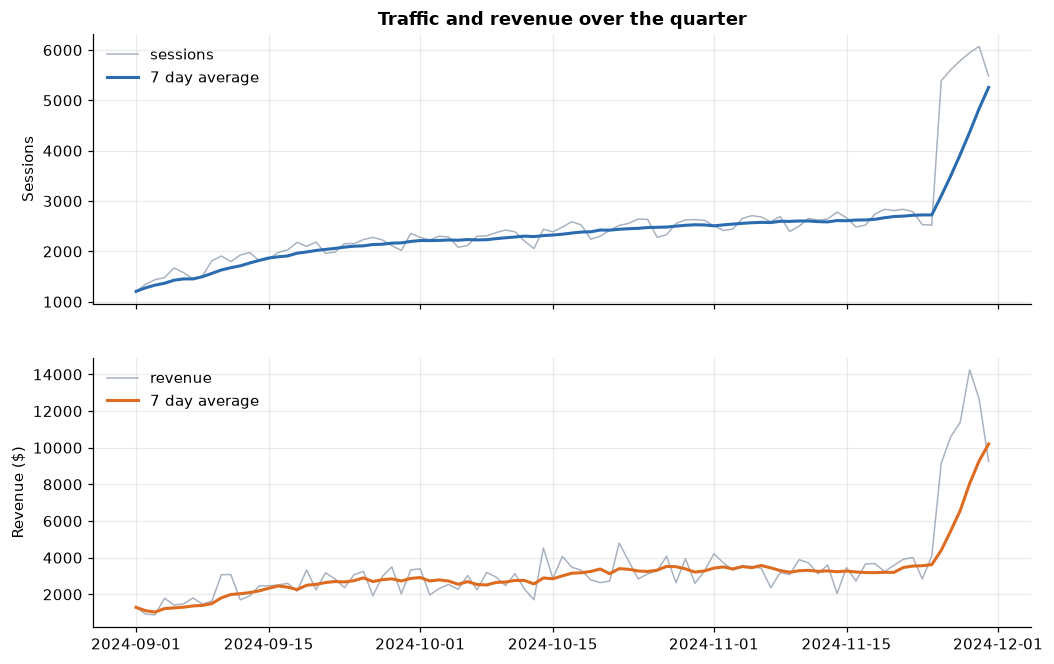

In [8]:
daily = metrics.daily_kpis()

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(daily["event_date"], daily["sessions"], color=viz.PALETTE[5], lw=1, alpha=0.6, label="sessions")
axes[0].plot(daily["event_date"], daily["sessions_7d_avg"], color=viz.PALETTE[0], lw=2, label="7 day average")
axes[0].set_ylabel("Sessions")
axes[0].legend(frameon=False)
axes[0].set_title("Traffic and revenue over the quarter")
axes[1].plot(daily["event_date"], daily["revenue"], color=viz.PALETTE[5], lw=1, alpha=0.6, label="revenue")
axes[1].plot(daily["event_date"], daily["revenue_7d_avg"], color=viz.PALETTE[1], lw=2, label="7 day average")
axes[1].set_ylabel("Revenue ($)")
axes[1].legend(frameon=False)
viz.save(fig, "01_traffic_and_revenue")

In [9]:
# Promo week is separated out. Using it inside a baseline would overstate what
# normal weeks look like.
daily["is_promo_week"] = daily["event_date"].between(pd.Timestamp("2024-11-25"), pd.Timestamp("2024-12-02"))
daily.groupby("is_promo_week")[["sessions", "revenue", "session_conversion_rate", "average_order_value"]].mean().round(3)

,sessions,revenue,session_conversion_rate,average_order_value
is_promo_week,,,,
False,2281.459,2882.748,0.018,69.104
True,5714.333,11215.762,0.028,71.003


'reports\\figures\\01_hour_of_day.png'

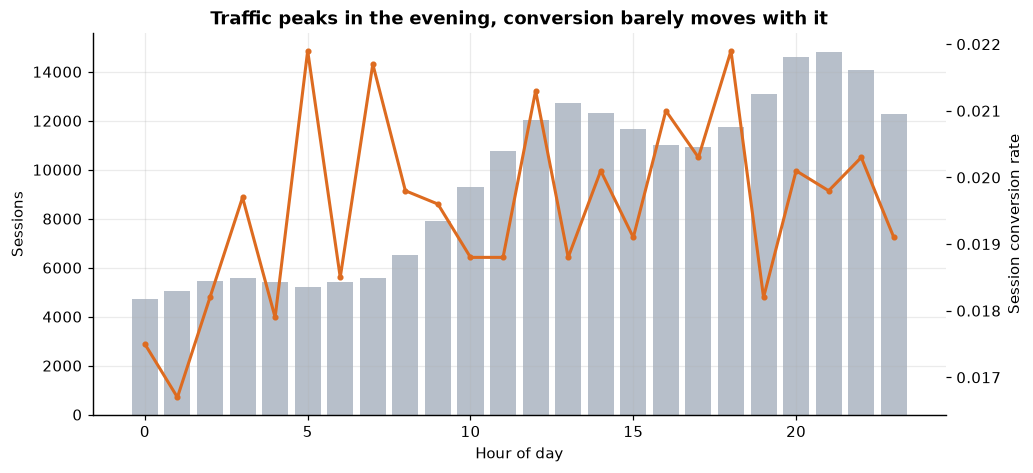

In [10]:
hourly = query("""
SELECT session_hour,
       count(*)                                              AS sessions,
       count(*) FILTER (WHERE purchased)                     AS purchases,
       round(count(*) FILTER (WHERE purchased) / count(*), 4) AS conversion_rate
FROM fct_funnel GROUP BY 1 ORDER BY 1
""")

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(hourly["session_hour"], hourly["sessions"], color=viz.PALETTE[5], alpha=0.5)
ax.set_ylabel("Sessions")
ax.set_xlabel("Hour of day")
ax2 = ax.twinx()
ax2.plot(hourly["session_hour"], hourly["conversion_rate"], color=viz.PALETTE[1], lw=2, marker="o", ms=3)
ax2.set_ylabel("Session conversion rate")
ax2.grid(False)
ax.set_title("Traffic peaks in the evening, conversion barely moves with it")
viz.save(fig, "01_hour_of_day")

In [11]:
# Same question for the day of week, which is what a weekly promo calendar
# would be planned around.
query("""
SELECT day_of_week,
       count(*)                                               AS sessions,
       round(count(*) FILTER (WHERE purchased) / count(*), 4)  AS conversion_rate,
       round(sum(session_revenue) / count(*), 2)               AS revenue_per_session
FROM fct_funnel
GROUP BY 1
ORDER BY sessions DESC
""")

,day_of_week,sessions,conversion_rate,revenue_per_session
0,Thursday,34706,0.0191,1.30
1,Friday,34540,0.0206,1.40
2,Wednesday,33891,0.0189,1.39
3,Tuesday,33424,0.0206,1.47
4,Monday,32812,0.0189,1.31
5,Saturday,31466,0.0205,1.38
6,Sunday,27371,0.0191,1.33


## What this sets up

The models pass the checks, so the funnel numbers can be taken at face value. The baseline to keep in mind for the rest of the project is roughly 2% of sessions converting, an average order around $70, and about a third of users coming back at least once.

Next: where inside the funnel those sessions are lost.